In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv('../data/raw/german_credit.data', sep=' ', header=None, names=[
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age', 'other_installment_plans',
    'housing', 'existing_credits', 'job', 'liable_people', 'telephone',
    'foreign_worker', 'risk'
])

# Convert target: 1 = Good Credit, 2 = Bad Credit
df['risk'] = df['risk'].map({1: 'Good Credit', 2: 'Bad Credit'})

print(df.shape)
df.head()

(1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,liable_people,telephone,foreign_worker,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,Good Credit
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,Bad Credit
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,Good Credit
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,Good Credit
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,Bad Credit


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account         1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment               1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status          1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [4]:
df.describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,liable_people
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


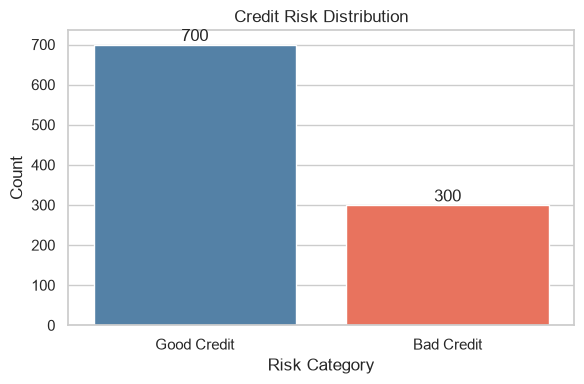

In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='risk', data=df, hue='risk', palette={'Good Credit': 'steelblue', 'Bad Credit': 'tomato'}, legend=False)
plt.title('Credit Risk Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/target_distribution.png')
plt.show()

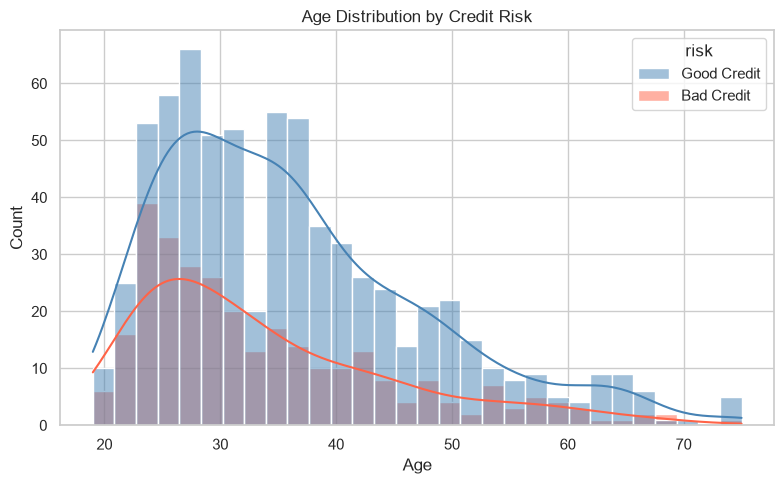

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='risk', bins=30, kde=True,
             palette={'Good Credit': 'steelblue', 'Bad Credit': 'tomato'})
plt.title('Age Distribution by Credit Risk')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/age_distribution.png')
plt.show()

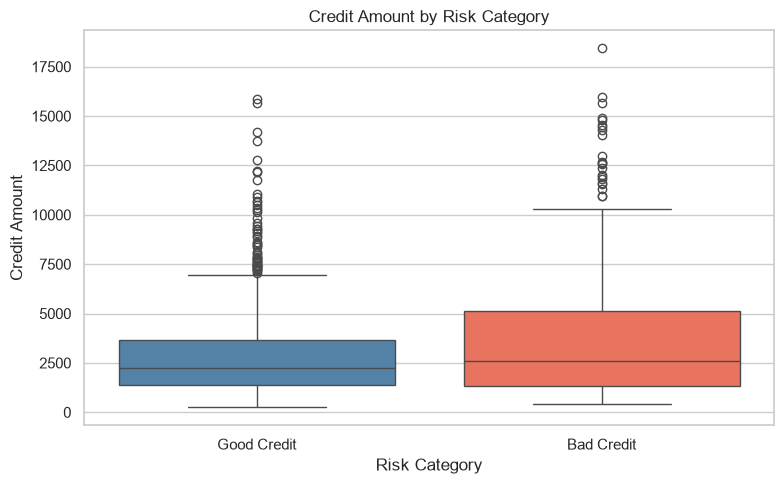

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='risk', y='credit_amount', hue='risk',
            palette={'Good Credit': 'steelblue', 'Bad Credit': 'tomato'}, legend=False)
plt.title('Credit Amount by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Credit Amount')
plt.tight_layout()
plt.savefig('../outputs/credit_amount_boxplot.png')
plt.show()

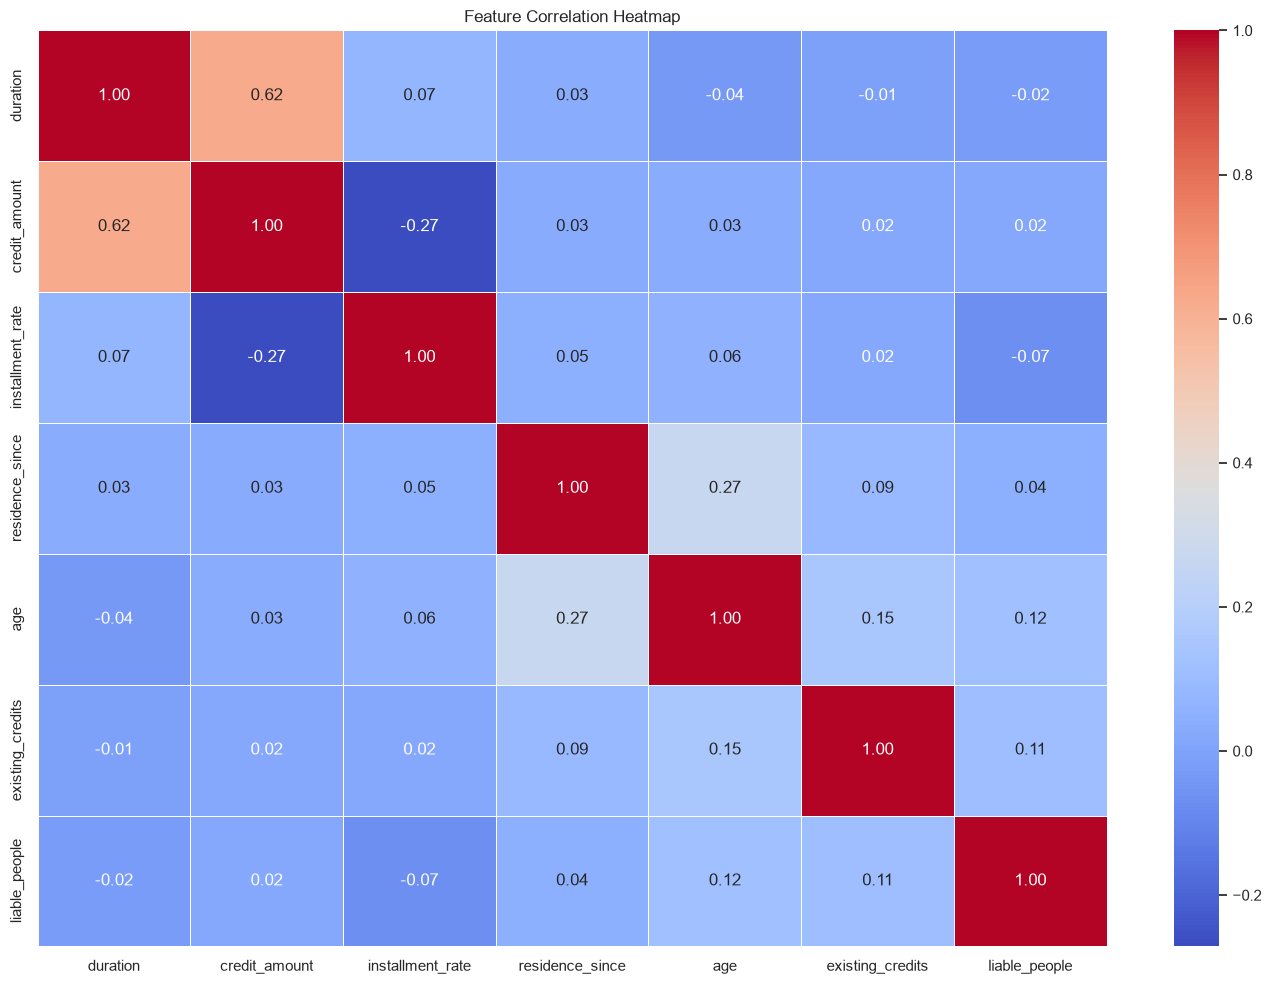

In [8]:
plt.figure(figsize=(14, 10))
numerical_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')
plt.show()

## Key Insights

- **70% of applicants** have good credit, meaning the dataset is moderately imbalanced
- **Younger applicants** tend to have slightly higher credit risk
- **Higher credit amounts** are associated with both good and bad credit, but bad credit cases show more outliers
- Duration and credit amount are the most correlated numerical features